## Dataset Overview

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("claims_train.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'claims_train.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542410 entries, 0 to 542409
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       542410 non-null  float64
 1   ClaimNb     542410 non-null  int64  
 2   Exposure    542410 non-null  float64
 3   Area        542410 non-null  object 
 4   VehPower    542410 non-null  int64  
 5   VehAge      542410 non-null  int64  
 6   DrivAge     542410 non-null  int64  
 7   BonusMalus  542410 non-null  int64  
 8   VehBrand    542410 non-null  object 
 9   VehGas      542410 non-null  object 
 10  Density     542410 non-null  int64  
 11  Region      542410 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 49.7+ MB


The training dataset contains **542,410 records** and **13 variables**.

- **Numerical features:** `IDpol`, `ClaimNb`, `Exposure`, `VehPower`, `VehAge`, `DrivAge`, `BonusMalus`, and `Density`
- **Categorical features:** `Area`, `VehBrand`, `VehGas`, and `Region`
- The variable **`IDpol`** was removed, as it serves only as a unique identifier and holds no predictive value.
- **No missing values** were detected in any of the columns.


In [ ]:
# Drop the IDpol column as it is not useful for analysis
df.drop("IDpol", axis=1, errors="ignore", inplace=True)

In [ ]:
df.describe()

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,542410.000000,542410.000000,542410.000000,542410.000000,542410.000000,542410.000000,542410.000000
mean,0.053122,0.528840,6.453281,7.045768,45.503164,59.761546,1796.176180
std,0.238785,0.364463,2.050506,5.660827,14.135435,15.639321,3965.475251
min,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1662.000000
max,11.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


### Summary of Numerical Features

- **Claims (`ClaimNb`)**: highly skewed — the mean is 0.0531 but the max reaches 11, meaning most policyholders report zero claims
- **Time insured (`Exposure`):** ranges from 0.0027 to 2.01, with a median around 0.49 (roughly half a year of risk exposure on average)
- **Vehicle power (`VehPower`)**: averages 6.45, mostly between 4 and 7, but some vehicles go up to 15 (high-performance cars)
- **Vehicle age (`VehAge`)**: has a median of 6 years, but some vehicles reach 100 years
- **Driver age (`DrivAge`)**: centers around 45 years, ranging from 18 to 100
- **Bonus-Malus (`BonusMalus`)**: mostly sits at 50, with a few extreme outliers up to 230
- **Population Density (`Density`)**: very uneven — median 393 vs max 27000, suggesting large variability across regions (urban vs rural)

**Takeaway:**  
Most policyholders have **no claims**, **moderate vehicle power**, and **limited exposure**, which does indicate realistic insurance scenarios.

Some features (like `VehAge`, `BonusMalus`, and `Density`) show **extreme outliers**, which might need **capping or transformation** during data cleaning.

Since `ClaimNb` is a potential target variable (label), we examined its distribution and found a **strong imbalance** — 94.98% of policyholders reported zero claims, while only 5.02% had one or more.  
The distribution also revealed a few **extreme outliers**, with up to **11 claims** recorded for a single policy.

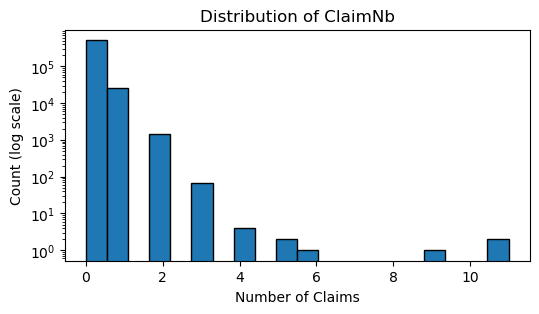

In [ ]:
plt.figure(figsize=(6, 3))
plt.hist(df["ClaimNb"], bins=20, edgecolor="black")
plt.yscale("log")
plt.title("Distribution of ClaimNb")
plt.xlabel("Number of Claims")
plt.ylabel("Count (log scale)")
plt.show()

Later on we discovered that having 11 claims in a year is not as bad/rare as **2 claims within just 18 hours of exposure** (Exposure = 0.0027 years). This indicates that **exposure duration** plays a crucial role in interpreting claim counts.  


### Claims per Year Exposure (ClaimRate)

To make claim activity **comparable across different exposure durations**, we derived a new variable called **Exposure-Normalized Claim Rate**, defined as:

$$
\text{ClaimRate} = \frac{\text{ClaimNb}}{\text{Exposure}}
$$

This transformation ensures that claim intensity is measured on a **consistent scale**, regardless of how long each policy was active.

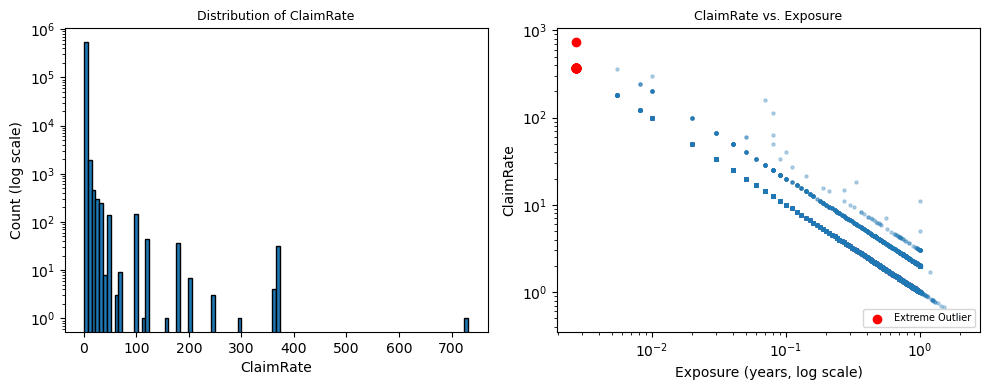

In [ ]:
# Calculate ClaimRate
df["ClaimRate"] = df["ClaimNb"] / df["Exposure"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
axes[0].hist(df["ClaimRate"], bins=100, edgecolor="black")
axes[0].set_yscale("log")
axes[0].set_title("Distribution of ClaimRate", fontsize=9)
axes[0].set_xlabel("ClaimRate")
axes[0].set_ylabel("Count (log scale)")

# After
extreme = df.loc[df["Exposure"] == df["Exposure"].min()] # To highlight extreme

axes[1].scatter(df["Exposure"], df["ClaimRate"], alpha=0.3, s=5)
axes[1].scatter(extreme["Exposure"], extreme["ClaimRate"], color="red", label="Extreme Outlier", zorder=5)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("ClaimRate vs. Exposure", fontsize=9)
axes[1].set_xlabel("Exposure (years, log scale)")
axes[1].set_ylabel("ClaimRate")
axes[1].legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

However, after further analysis, we decided **not to** use ClaimRate as our target variable for modeling.

While the **ClaimRate** (claims per year of exposure) initially seemed like a fairer measure of claim activity, in practice it introduced more complications than benefits for our predictive goal.  

- **Prediction context:**  
  Our task (based on our understanding) was to estimate the *expected number of claims* for a new client. For such a case, the **exposure** value is already known (from the contract), but the **claim count** is not. Modeling ClaimRate would still require re-scaling the output by exposure afterward — essentially adding an unnecessary transformation step.

- **Interpretation issue:**  
  Comparing clients based on their claim rate doesn't reflect real business impact. Whether a policyholder made 3 claims in a month or in a year, both cases represent a loss. The time-adjusted comparison adds statistical fairness, but not practical relevance in terms of company cost.

- **Potential correlation conflict:**  
  Using ClaimRate as the dependent variable might introduce a **direct relationship between the target and the Exposure feature** (since Exposure is in the denominator). This risks leaking information into the model, creating bias or inflated performance metrics.

- **Practical outcome:**  
  Even if the model predicted ClaimRate, we would still need to multiply it by exposure to get the actual **number of claims**, because not all contracts have equal duration. This makes the process unnecessarily indirect.  

For these reasons, we decided to model the **ClaimNb (number of claims)** directly, while keeping **Exposure** as a separate explanatory variable.

## Data Cleaning

Now, we go through all variables one by one checking for outliers, starting with **ClaimNb**.  
As stated before, 95% of the cases correspond to zero claims and only 5% are non-zero.  
If we included the zeros, every non-zero value would technically be seen as an outlier.  

Since our goal is to build a model that predicts the number of claims given the features, we must **retain non-zero observations** to capture patterns of actual claims.   
However, including extreme values (outliers) within the non-zero subset would make the model fit to rare, extreme cases and lead to **overestimation** for the general population.  

To prevent this, we focus on the **non-zero subset**.  
Since the IQR rule cannot detect meaningful upper outliers, we applied a **percentile-based approach** instead, clipping all values above the **99.5th percentile**.  
Values are **clipped** rather than removed, so we keep all claim cases while reducing distortion from extreme outliers.

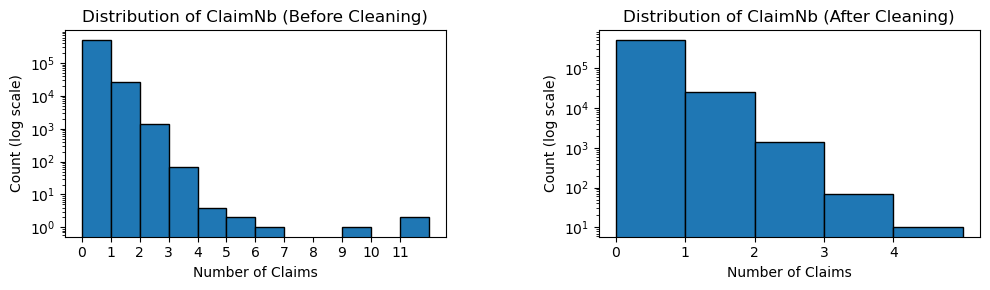

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["ClaimNb"], bins=range(int(df["ClaimNb"].max()) + 2), edgecolor="black")
axes[0].set_yscale("log")
axes[0].set_title("Distribution of ClaimNb (Before Cleaning)")
axes[0].set_xlabel("Number of Claims")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_xticks(range(int(df["ClaimNb"].max()) + 1))

# Clean
cap_value = df.loc[df["ClaimNb"] > 1, "ClaimNb"].quantile(0.995)
df["ClaimNb"] = np.where(df["ClaimNb"] > cap_value, cap_value, df["ClaimNb"])

# After
axes[1].hist(df["ClaimNb"], bins=range(int(df["ClaimNb"].max()) + 2), edgecolor="black", color="#1f77b4")
axes[1].set_yscale("log")
axes[1].set_title("Distribution of ClaimNb (After Cleaning)")
axes[1].set_xlabel("Number of Claims")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_xticks(range(int(df["ClaimNb"].max()) + 1))

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

Moving onto the **Exposure** variable, as described earlier, it represents the **time at risk**, i.e. the duration (in years) a policy was active and exposed to potential claims.  
Most records fall within the expected range of **0–1 year**, corresponding to partial or full-year coverage.  

However, a few policies show **Exposure values greater than 1**, which likely indicate *errors in the dataset*.  

Given that our data represents historical records intended to show **the number of claims per year**, an exposure above one year would not make sense in this context. A record containing both the number of claims and an exposure longer than one year would only represent an **average annualized claim rate** rather than the actual observed count within a single year.  

To maintain consistency and ensure that all records reflect comparable one-year observation windows, we **cap the Exposure values at 1.0**.

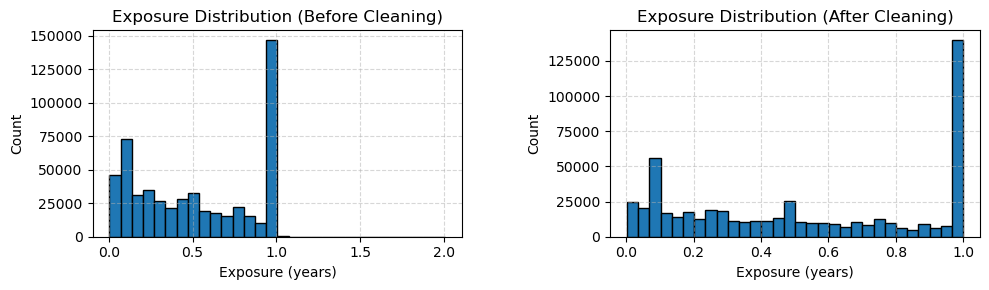

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["Exposure"], bins=30, edgecolor="black")
axes[0].set_title("Exposure Distribution (Before Cleaning)")
axes[0].set_xlabel("Exposure (years)")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Clean
cap_value = 1.0
df["Exposure"] = np.where(df["Exposure"] > cap_value, cap_value, df["Exposure"])

# After
axes[1].hist(df["Exposure"], bins=30, edgecolor="black", color="#1f77b4")
axes[1].set_title("Exposure Distribution (After Cleaning)")
axes[1].set_xlabel("Exposure (years)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

The next numerical variable is **VehAge**, which represents the age of the vehicle in years.  
From the distribution, it is clear that vehicles older than **around 25 years** are extremely rare and not representative of the general insured population.  

To prevent these extreme values from skewing the model, we applied a **quantile-based cap**. Specifically, we limited `VehAge` to the **99.5th percentile**, which corresponds to about **24 years**.

VehAge: capped above 24.00


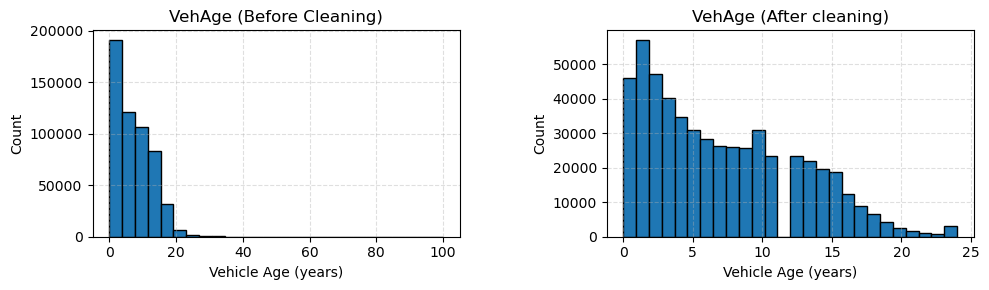

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["VehAge"], bins=26, edgecolor="black")
axes[0].set_title("VehAge (Before Cleaning)")
axes[0].set_xlabel("Vehicle Age (years)")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Clean
cap_value =  df["VehAge"].quantile(0.995)
print(f"VehAge: capped above {cap_value:.2f}")

df["VehAge"] = df["VehAge"].clip(upper=cap_value)

# After
axes[1].hist(df["VehAge"], bins=26, edgecolor="black", color="#1f77b4")
axes[1].set_title("VehAge (After cleaning)")
axes[1].set_xlabel("Vehicle Age (years)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

**DrivAge** represents the age of the driver, whose values mostly fall between **18 and 86.5 years**, consistent with legal and realistic limits for insured individuals.  

Extremely high ages are rare and may introduce noise into the model rather than providing meaningful predictive value.

To address this, we applied a **quantile-based upper cap** at the **99.5th percentile** (approximately **83 years**), limiting the influence of extreme cases.

DrivAge: capped above 83.00


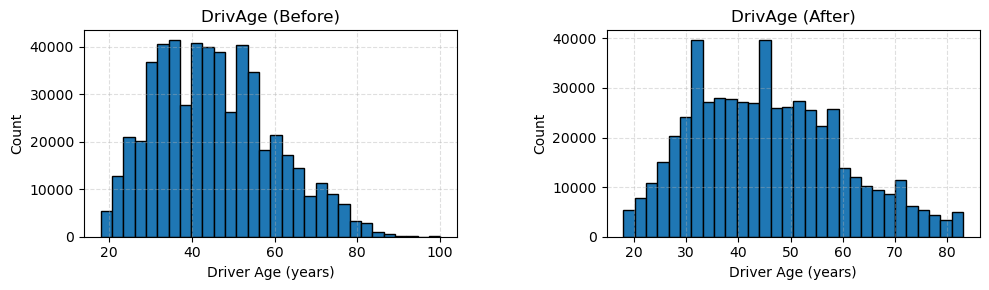

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["DrivAge"], bins=30, edgecolor="black")
axes[0].set_title("DrivAge (Before)")
axes[0].set_xlabel("Driver Age (years)")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Clean
cap_value = df["DrivAge"].quantile(0.995)
print(f"DrivAge: capped above {cap_value:.2f}")

df["DrivAge"] = df["DrivAge"].clip(upper=cap_value)

# After
axes[1].hist(df["DrivAge"], bins=30, edgecolor="black", color="#1f77b4")
axes[1].set_title("DrivAge (After)")
axes[1].set_xlabel("Driver Age (years)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

The **BonusMalus** variable represents the driver's penalty factor.  
Most policyholders have values around **50**, indicating a neutral risk profile, while higher numbers represent penalties due to previous claims.  

The distribution shows that **values above 118 are extremely rare** and would only distort the model — the same issues as discussed earlier may occur here as well.

In this scenario, we **cap BonusMalus at 118**, ensuring the variable remains within a realistic and interpretable range and in the meantime preventing extreme penalty values from dominating the model.

BonusMalus: capped above 118.00


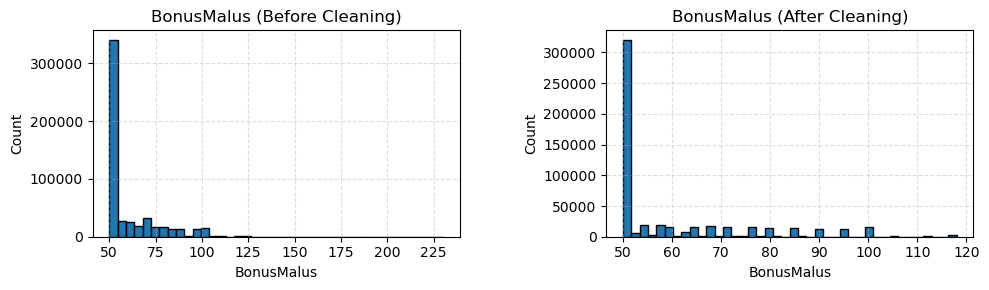

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["BonusMalus"], bins=40, edgecolor="black")
axes[0].set_title("BonusMalus (Before Cleaning)")
axes[0].set_xlabel("BonusMalus")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Clean
cap_value = df["BonusMalus"].quantile(0.995)
print(f"BonusMalus: capped above {cap_value:.2f}")

df["BonusMalus"] = df["BonusMalus"].clip(upper=cap_value)

# After
axes[1].hist(df["BonusMalus"], bins=40, edgecolor="black", color="#1f77b4")
axes[1].set_title("BonusMalus (After Cleaning)")
axes[1].set_xlabel("BonusMalus")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

Lastly, we examine the **Density** variable, representing the population density of the policyholder’s region.  
The distribution is highly right-skewed — most policyholders live in low- to medium-density areas, while a few records correspond to extremely urban regions with densities exceeding **20,000 inhabitants/km²**.  

These high values are valid but heavily distort the scale of the variable.  
Instead of capping them, we apply a **logarithmic transformation** to reduce skewness while preserving the relative differences between rural and urban regions.  

The transformed variable, `Density`, provides a more balanced representation of regional density and will be used for further analysis and modeling.

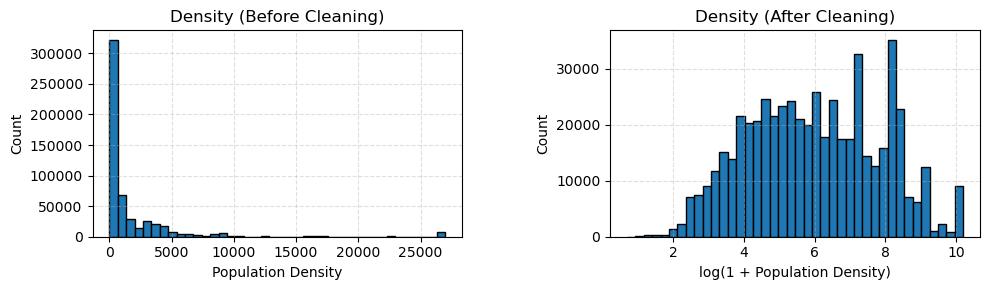

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Before
axes[0].hist(df["Density"], bins=40, edgecolor="black")
axes[0].set_title("Density (Before Cleaning)")
axes[0].set_xlabel("Population Density")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Clean
df["Density"] = np.log1p(df["Density"])

# After
axes[1].hist(df["Density"], bins=40, edgecolor="black", color="#1f77b4")
axes[1].set_title("Density (After Cleaning)")
axes[1].set_xlabel("log(1 + Population Density)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()